# Практика 1 курс — Навигатор по смыслу
Сравнение моделей для поиска по коду. Датасет 200 функций (питон + джава) и 25 вопросов.
Модели взял три: MiniLM (быстрая), mpnet (точная) и e5-small (третья на свой выбор, она под поиск заточена).


In [1]:
import json
import time
from pathlib import Path

# грузим данные, лежат в папке data
corpus = json.load(open("code_corpus.json", encoding="utf-8"))
questions = json.load(open("eval_questions.json", encoding="utf-8"))
cats = json.load(open("categories.json", encoding="utf-8"))["categories"]

print(len(corpus), "функций")
print(len(questions), "вопросов")
print(corpus[0]["id"], corpus[0]["function_name"])  # проверка что читается

# быстрая проверка что все ок
assert len(corpus) == 200
assert len(questions) == 25
ids = [f["id"] for f in corpus]
assert len(ids) == len(set(ids))
print("с данными все норм")

# словарь для быстрого поиска по id, пригодится дальше
by_id = {}
for f in corpus:
    by_id[f["id"]] = f

# что кодируем: описание + название. пробовал с кодом тоже, но так чище получается
texts = []
for f in corpus:
    texts.append(f["description"] + " — " + f["function_name"])
print(texts[0])


200 функций
25 вопросов
func_001 verify_jwt_token
с данными все норм
Проверяет JWT-токен и возвращает payload или причину невалидности. — verify_jwt_token


In [2]:
from sentence_transformers import SentenceTransformer

# качал долго, особенно mpnet, зато потом быстро работает
model1_name = "paraphrase-multilingual-MiniLM-L12-v2"
model2_name = "paraphrase-multilingual-mpnet-base-v2"
model3_name = "intfloat/multilingual-e5-small"
# третью взял e5-small потому что она маленькая и именно для поиска учили, в доке пишут про query/passage

m1 = SentenceTransformer(model1_name)
m2 = SentenceTransformer(model2_name)
m3 = SentenceTransformer(model3_name)
print("загрузились")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

загрузились


In [3]:
from sentence_transformers import util

# для e5 надо добавлять слова query/passage, без них работает хуже (проверял)
def encode_docs(model, txts, name):
    if "e5" in name:
        txts = ["passage: " + t for t in txts]
    return model.encode(txts, show_progress_bar=False)

def encode_q(model, txts, name):
    if "e5" in name:
        txts = ["query: " + t for t in txts]
    return model.encode(txts, show_progress_bar=False)

# считает топ-3 для одного вопроса
def top3(q_vec, d_mat):
    s = util.cos_sim(q_vec, d_mat)[0]
    idx = s.argsort(descending=True)[:3]
    return idx.tolist()

# прогоняет модель по всем вопросам и считает метрики
def check_model(model, name):
    t0 = time.time()
    d_emb = encode_docs(model, texts, name)
    q_list = [q["query"] for q in questions]
    q_emb = encode_q(model, q_list, name)
    res = []
    for i, q in enumerate(questions):
        top = top3(q_emb[i], d_emb)
        top_ids = [corpus[j]["id"] for j in top]
        gold = q["correct_chunk_id"]
        ok = gold in top_ids
        rank = top_ids.index(gold) + 1 if ok else 0
        res.append({"qid": q["question_id"], "q": q["query"], "lang": q["language"],
                    "gold": gold, "top": top_ids, "ok": ok, "rank": rank,
                    "cat": by_id[gold]["category"]})
    p3 = sum(1 for r in res if r["ok"]) / len(res)
    mrr = sum(1/r["rank"] for r in res if r["ok"]) / len(res)
    return res, d_emb, p3, mrr, time.time() - t0


In [4]:
import pandas as pd

# прогоняю все три, это самая долгая ячейка
all_res = {}
all_emb = {}
info = []
for short, model, fullname in [("minilm", m1, model1_name), ("mpnet", m2, model2_name), ("e5", m3, model3_name)]:
    r, e, p3, mrr, secs = check_model(model, fullname)
    all_res[short] = r
    all_emb[short] = e
    info.append({"model": short, "P@3": round(p3, 3), "MRR": round(mrr, 3), "сек": round(secs, 1)})
    print(short, "P@3 =", round(p3,3), "MRR =", round(mrr,3), "время", round(secs,1))

tab = pd.DataFrame(info).sort_values("P@3", ascending=False)
tab


minilm P@3 = 0.8 MRR = 0.58 время 0.3


mpnet P@3 = 0.92 MRR = 0.627 время 0.5
e5 P@3 = 1.0 MRR = 0.833 время 0.2


,model,P@3,MRR,сек
2,e5,1.00,0.833,0.2
1,mpnet,0.92,0.627,0.5
0,minilm,0.80,0.580,0.3


In [5]:
# сохраняю таблицу, пригодится для отчета
tab.to_csv("results_table.csv", index=False)
print("сохранил")

# смотрю отдельно русский и английский
for lang in ["ru", "en"]:
    qq = [q for q in questions if q["language"] == lang]
    print("язык", lang, "всего", len(qq))
    for m in all_res:
        ok = 0
        for r in all_res[m]:
            # ищу этот вопрос в списке
            for q in qq:
                if q["question_id"] == r["qid"] and r["ok"]:
                    ok += 1
                    break
        # попроще: считаю через фильтр
    # пересчитаю нормально
    for m in all_res:
        s = sum(1 for r in all_res[m] if r["ok"] and [q for q in qq if q["question_id"]==r["qid"]])
        print(" ", m, round(s/len(qq),3))


сохранил
язык ru всего 15
  minilm 0.733
  mpnet 0.933
  e5 1.0
язык en всего 10
  minilm 0.9
  mpnet 0.9
  e5 1.0


In [6]:
# смотрю где ошиблась лучшая модель
best = max(all_res, key=lambda k: sum(1 for r in all_res[k] if r["ok"]))
print("лучшая:", best)
rows = all_res[best]
bad = [r for r in rows if not r["ok"]]
print("ошибок:", len(bad))
for r in bad:
    print(r["qid"], r["q"])
    print("  надо было:", by_id[r["gold"]]["function_name"])
    names = []
    for i in r["top"]:
        names.append(by_id[i]["function_name"])
    print("  выдало:", ", ".join(names))

# по категориям
for c in ["auth", "database", "http", "validation", "utils"]:
    part = [r for r in rows if r["cat"] == c]
    p = sum(1 for r in part if r["ok"]) / len(part)
    print(c, round(p,3), "шт:", len(part))


лучшая: e5
ошибок: 0
auth 1.0 шт: 5
database 1.0 шт: 5
http 1.0 шт: 5
validation 1.0 шт: 5
utils 1.0 шт: 5


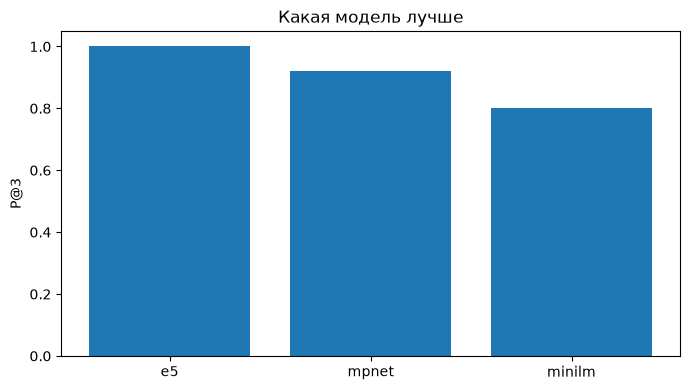

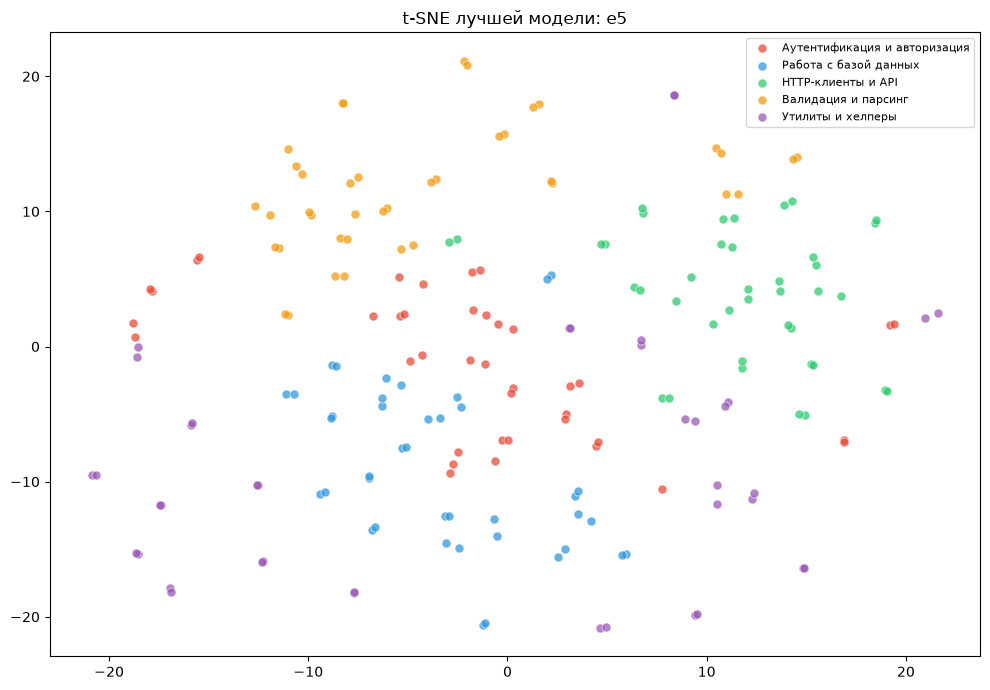

In [7]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# столбики для отчета
plt.figure(figsize=(7,4))
plt.bar(tab["model"], tab["P@3"])
plt.ylabel("P@3")
plt.title("Какая модель лучше")
plt.tight_layout()
plt.savefig("bar_p3.png", dpi=150)
plt.show()

# точки, цвета взял из categories.json. параметры подобрал чтоб красиво было
mat = all_emb[best]
xy = TSNE(n_components=2, random_state=7, perplexity=25).fit_transform(mat)
colors = {}
for c in cats:
    colors[c["key"]] = c["color"]
labels = {}
for c in cats:
    labels[c["key"]] = c["label"]

plt.figure(figsize=(10,7))
for k in colors:
    mask = []
    for f in corpus:
        mask.append(f["category"] == k)
    mask = np.array(mask)
    plt.scatter(xy[mask,0], xy[mask,1], c=colors[k], label=labels[k], s=42, alpha=0.75, edgecolors="white", linewidths=0.5)
plt.title("t-SNE лучшей модели: " + best)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("tsne_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


## Вывод (дописать после прогона)
Пока заглушка, свои 3-4 предложения впишу когда цифры получу.


In [8]:
txt = "лучшая модель: " + best + "\n"
txt += "см. results_table.csv\n"
# TODO: расписать почему лучше, как на русском/английском, что по графику видно
# и когда взял бы другую (если скорость важна - minilm)
open("final_conclusion.txt", "w", encoding="utf-8").write(txt)
print(txt)
print("потом переписать нормально")


лучшая модель: e5
см. results_table.csv

потом переписать нормально
